In [1]:
import pandas as pd

df = pd.read_csv("amr_data.csv")
print(df.shape)
print(df.columns.tolist())
print(df.head())

(25000, 21)
['Taxon ID', 'Genome ID', 'Genome Name', 'Antibiotic', 'Resistant Phenotype', 'Measurement', 'Measurement Sign', 'Measurement Value', 'Measurement Unit', 'Laboratory Typing Method', 'Laboratory Typing Method Version', 'Laboratory Typing Platform', 'Vendor', 'Testing Standard', 'Testing Standard Year', 'Computational Method', 'Computational Method Version', 'Computational Method Performance', 'Evidence', 'Source', 'PubMed']
   Taxon ID    Genome ID                            Genome Name  \
0       573    573.23123      Klebsiella pneumoniae strain PN84   
1     28901  28901.24388          Salmonella enterica A038_2016   
2       562    562.56783         Escherichia coli strain 372-13   
3      1280   1280.16599     Staphylococcus aureus strain CM138   
4      1773   1773.20364  Mycobacterium tuberculosis ERR1034913   

      Antibiotic Resistant Phenotype Measurement Measurement Sign  \
0       imipenem         Susceptible         NaN              NaN   
1   azithromycin    

In [2]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Import Successful")

Import Successful


In [3]:
df = pd.read_csv("amr_data.csv")

# Keep only relevant columns
df = df[["Genome Name", "Antibiotic", "Resistant Phenotype", 
         "Measurement Value", "Laboratory Typing Method", 
         "Testing Standard", "Source"]]

# Rename for easier use
df.columns = ["species", "antibiotic", "phenotype", 
              "mic_value", "method", "standard", "source"]

# Remove rows where phenotype is missing — that's our target
df = df.dropna(subset=["phenotype"])

# Clean phenotype values
print("Phenotype values:", df["phenotype"].unique())
print(f"\nShape after cleaning: {df.shape}")
print(df.head())

Phenotype values: <StringArray>
[           'Susceptible',              'Resistant',           'Intermediate',
         'Nonsusceptible', 'Reduced Susceptibility']
Length: 5, dtype: str

Shape after cleaning: (24732, 7)
                                 species     antibiotic    phenotype  \
0      Klebsiella pneumoniae strain PN84       imipenem  Susceptible   
1          Salmonella enterica A038_2016   azithromycin  Susceptible   
2         Escherichia coli strain 372-13  ciprofloxacin    Resistant   
3     Staphylococcus aureus strain CM138  ciprofloxacin    Resistant   
4  Mycobacterium tuberculosis ERR1034913      kanamycin  Susceptible   

  mic_value          method standard  source  
0       NaN             NaN      NaN     NaN  
1         4             MIC     CLSI     NaN  
2       NaN  Disk diffusion   EUCAST     NaN  
3       NaN             NaN      NaN     NaN  
4       NaN             NaN      NaN     NaN  


In [5]:
print("Top 10 species:")
print(df["species"].value_counts().head(10))

print("\nTop 10 antibiotics:")
print(df["antibiotic"].value_counts().head(10))

print("\nResistance phenotype distribution:")
print(df["phenotype"].value_counts())

Top 10 species:
species
Streptococcus pneumoniae strain GPSC3                                                                                                                                                20
Mycobacterium tuberculosis                                                                                                                                                           20
Klebsiella pneumoniae strain Prospectively collected (P) strain Prospectively collected (P) strain Prospectively collected (P)                                                       20
Streptococcus pneumoniae strain GPSC10                                                                                                                                               18
Streptococcus pneumoniae strain GPSC5                                                                                                                                                18
Klebsiella pneumoniae strain Previously collected from b

In [6]:
# Extract just the main species name (first two words)
df["species"] = df["species"].apply(lambda x: " ".join(str(x).split()[:2]))

# Keep only the main phenotypes
df = df[df["phenotype"].isin(["Resistant", "Susceptible", "Intermediate"])]

print("Cleaned species:")
print(df["species"].value_counts().head(10))
print(f"\nShape after cleaning: {df.shape}")
print("\nPhenotype distribution:")
print(df["phenotype"].value_counts())

Cleaned species:
species
Klebsiella pneumoniae         7534
Mycobacterium tuberculosis    6300
Streptococcus pneumoniae      3075
Staphylococcus aureus         2382
Salmonella enterica           1527
Escherichia coli              1352
Acinetobacter baumannii        635
Neisseria gonorrhoeae          472
Pseudomonas aeruginosa         344
Shigella sonnei                311
Name: count, dtype: int64

Shape after cleaning: (24685, 7)

Phenotype distribution:
phenotype
Susceptible     16446
Resistant        7958
Intermediate      281
Name: count, dtype: int64


In [7]:
# Keep only top 7 most common species for cleaner analysis
top_species = df["species"].value_counts().head(7).index.tolist()
df = df[df["species"].isin(top_species)]

print("Final species in dataset:")
print(df["species"].value_counts())
print(f"\nFinal shape: {df.shape}")

Final species in dataset:
species
Klebsiella pneumoniae         7534
Mycobacterium tuberculosis    6300
Streptococcus pneumoniae      3075
Staphylococcus aureus         2382
Salmonella enterica           1527
Escherichia coli              1352
Acinetobacter baumannii        635
Name: count, dtype: int64

Final shape: (22805, 7)


<Figure size 1400x700 with 0 Axes>

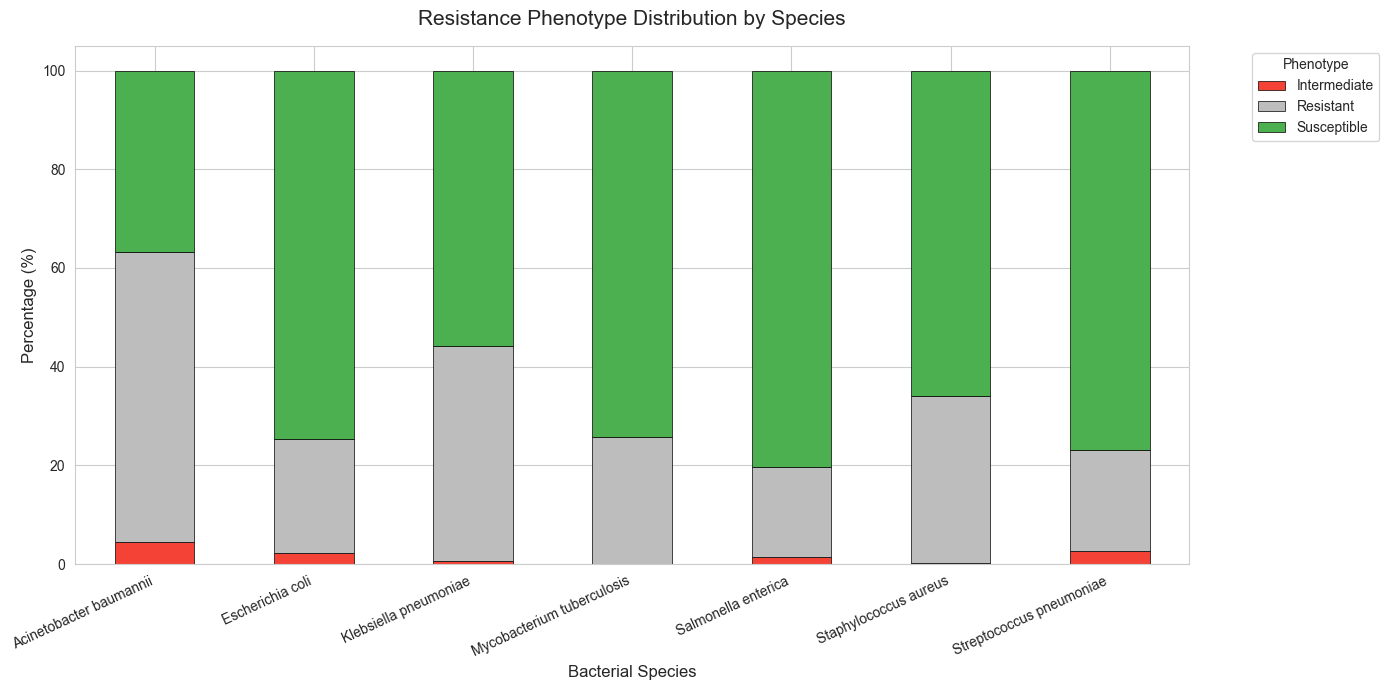

Plot 1 done!


In [8]:
# Plot 1: Resistance Distribution by Species
plt.figure(figsize=(14, 7))
species_phenotype = df.groupby(["species", "phenotype"]).size().unstack(fill_value=0)
species_phenotype_pct = species_phenotype.div(species_phenotype.sum(axis=1), axis=0) * 100

species_phenotype_pct.plot(kind="bar", stacked=True, 
                           color=["#f44336", "#bdbdbd", "#4caf50"],
                           figsize=(14, 7), edgecolor="black", linewidth=0.5)

plt.title("Resistance Phenotype Distribution by Species", fontsize=15, pad=15)
plt.xlabel("Bacterial Species", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Phenotype", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("resistance_by_species.png", dpi=150)
plt.show()
print("Plot 1 done!")

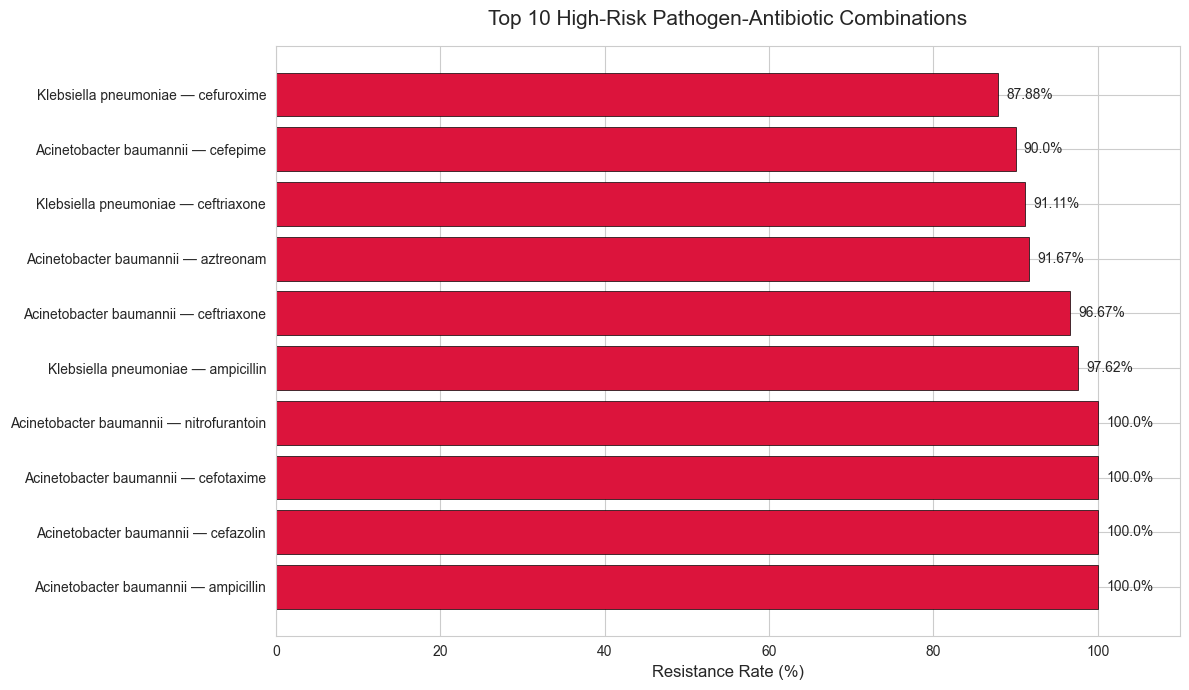

Plot 2 done!


In [9]:
# Plot 2: Top 10 Most Resistanct Antibiotic Species Combinations
# Calculate resistance rate per species-antibiotic combination
df["is_resistant"] = (df["phenotype"] == "Resistant").astype(int)
combo = df.groupby(["species", "antibiotic"]).agg(
    total=("is_resistant", "count"),
    resistant=("is_resistant", "sum")
).reset_index()
combo["resistance_rate"] = (combo["resistant"] / combo["total"] * 100).round(2)
combo = combo[combo["total"] >= 10]  # only keep combos with enough data
top_combos = combo.nlargest(10, "resistance_rate")

plt.figure(figsize=(12, 7))
bars = plt.barh(
    top_combos["species"] + " — " + top_combos["antibiotic"],
    top_combos["resistance_rate"],
    color="crimson", edgecolor="black", linewidth=0.5
)
plt.xlabel("Resistance Rate (%)", fontsize=12)
plt.title("Top 10 High-Risk Pathogen-Antibiotic Combinations", fontsize=15, pad=15)
plt.xlim(0, 110)
for bar, val in zip(bars, top_combos["resistance_rate"]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{val}%", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("top_resistant_combos.png", dpi=150)
plt.show()
print("Plot 2 done!")

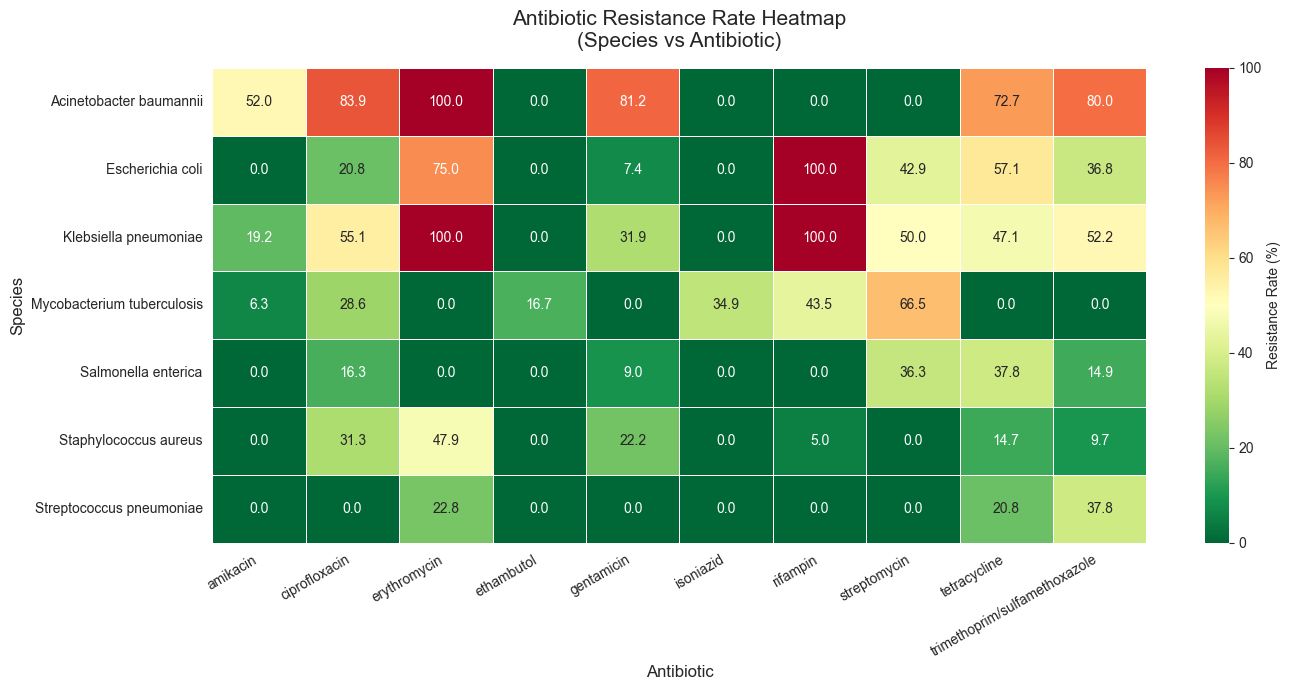

Plot 3 done!


In [10]:
# Plot 3: Resistance Heatmap
# Top 7 species vs top 10 antibiotics
top_antibiotics = df["antibiotic"].value_counts().head(10).index.tolist()
heatmap_df = df[df["antibiotic"].isin(top_antibiotics)]

pivot = heatmap_df.groupby(["species", "antibiotic"])["is_resistant"].mean() * 100
pivot = pivot.unstack(fill_value=0).round(1)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Resistance Rate (%)"})
plt.title("Antibiotic Resistance Rate Heatmap\n(Species vs Antibiotic)", 
          fontsize=15, pad=15)
plt.xlabel("Antibiotic", fontsize=12)
plt.ylabel("Species", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("resistance_heatmap.png", dpi=150)
plt.show()
print("Plot 3 done!")

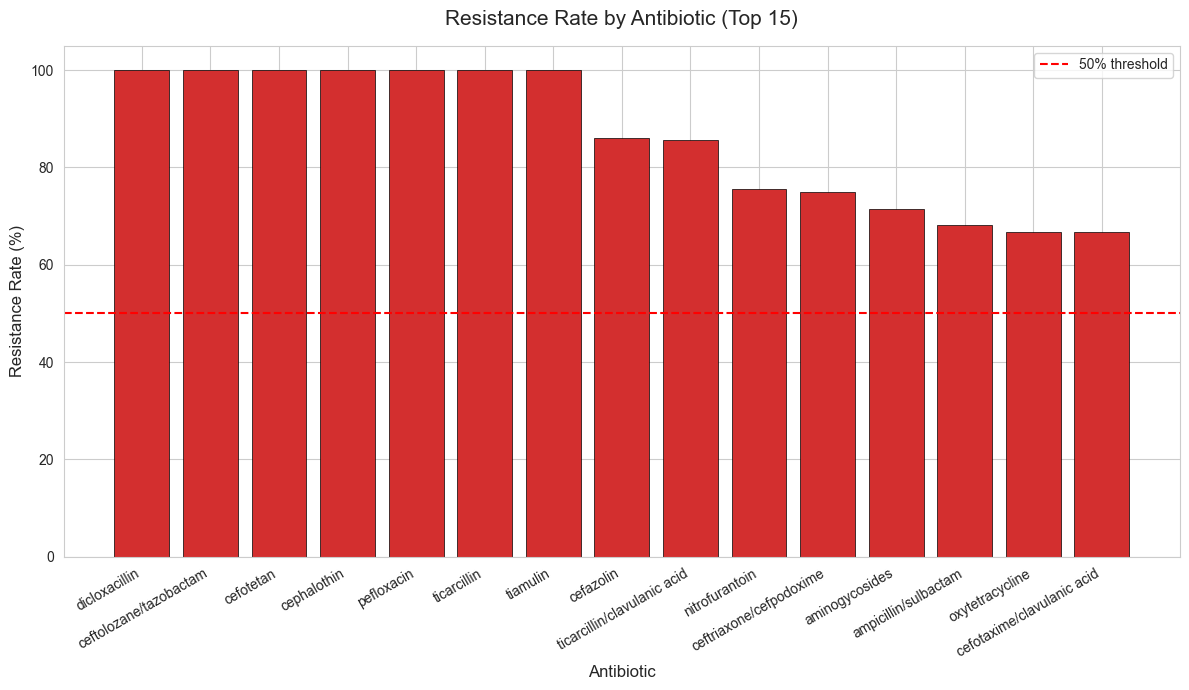

Plot 4 done!


In [11]:
# Plot 4: Overall Resistance Rate per Antibiotic
antibiotic_resistance = df.groupby("antibiotic")["is_resistant"].mean() * 100
antibiotic_resistance = antibiotic_resistance.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 7))
colors = ["#d32f2f" if x > 50 else "#ff9800" if x > 25 else "#4caf50" 
          for x in antibiotic_resistance.values]
bars = plt.bar(antibiotic_resistance.index, antibiotic_resistance.values,
               color=colors, edgecolor="black", linewidth=0.5)
plt.axhline(y=50, color="red", linestyle="--", linewidth=1.5, label="50% threshold")
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.title("Resistance Rate by Antibiotic (Top 15)", fontsize=15, pad=15)
plt.ylabel("Resistance Rate (%)", fontsize=12)
plt.xlabel("Antibiotic", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("resistance_by_antibiotic.png", dpi=150)
plt.show()
print("Plot 4 done!")